In [ ]:
# ============================================================
# Cell 1: Mount Google Drive & ensure save folder exists
# ============================================================
from google.colab import drive
import os

drive.mount("/content/drive")

SAVE_DIR = "/content/drive/MyDrive/CoCare/intent_Eng"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"✅ Drive mounted.")
print(f"✅ Save directory ready: {SAVE_DIR}")

In [14]:
!pip install -q transformers datasets scikit-learn nltk openpyxl

In [17]:
from __future__ import annotations
from sklearn.metrics import f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import json
import os
import random
import re
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

# =========================================================
# PATHS
# =========================================================
BASE_DIR = Path("/content/drive/MyDrive/CoCare/intent_Eng")

MAIN_DATASET_PATH = BASE_DIR / "merged_telecom_13intents_balanced_en.csv"
RESPONSE_MAP_PATH = BASE_DIR / "intent_response_map_en.csv"
FOLLOWUP_MAP_PATH = BASE_DIR / "intent_follow_up_map_en.csv"

MODEL_DIR = BASE_DIR / "distilbert_intent_model_only"
REPORT_PATH = BASE_DIR / "distilbert_intent_report.json"
LABEL_ENCODER_PATH = BASE_DIR / "distilbert_label_encoder.pkl"

MAX_BERT_LENGTH = 128
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# =========================================================
# NLTK
# =========================================================
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

for resource_path, download_name in [
    ("corpora/stopwords", "stopwords"),
    ("corpora/wordnet", "wordnet"),
    ("corpora/omw-1.4", "omw-1.4"),
]:
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(download_name, quiet=True)

EN_STOPWORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

# =========================================================
# TRANSFORMERS
# =========================================================
import torch
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

# =========================================================
# TYPO NORMALIZATION
# =========================================================
TELECOM_TYPO_MAP = {
    "interent": "internet",
    "intrnet": "internet",
    "netwrok": "network",
    "pakage": "package",
    "renewel": "renewal",
    "billng": "billing",
    "paymnt": "payment",
    "roamingg": "roaming",
    "recharje": "recharge",
    "complian": "complaint",
    "conection": "connection",
    "disconnecton": "disconnection",
    "simm": "sim",
    "balnce": "balance",
    "slwo": "slow",
}

# =========================================================
# HELPERS
# =========================================================
def set_global_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def normalize_typos(text: str) -> str:
    tokens = text.split()
    fixed = [TELECOM_TYPO_MAP.get(tok, tok) for tok in tokens]
    return " ".join(fixed)

def preprocess_text(text: Any) -> str:
    text = "" if pd.isna(text) else str(text)
    text = text.lower()
    text = normalize_typos(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def save_json(path: Path, data: Dict[str, Any]) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

def compute_metrics_block(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, Any]:
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    return {
        "accuracy": round(float(acc), 4),
        "precision_weighted": round(float(precision), 4),
        "recall_weighted": round(float(recall), 4),
        "f1_weighted": round(float(f1), 4),
        "confusion_matrix": cm.tolist(),
    }

# =========================================================
# DATA LOADING
# =========================================================
def read_csv_file(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    return pd.read_csv(path)

def detect_main_columns(df: pd.DataFrame):
    cols_lower = {c.lower(): c for c in df.columns}

    text_col_candidates = ["text", "utterance", "message", "query", "sentence", "customer_text"]
    label_col_candidates = ["intent", "label", "class", "category", "intent_label"]

    text_col = next((cols_lower[c] for c in text_col_candidates if c in cols_lower), None)
    label_col = next((cols_lower[c] for c in label_col_candidates if c in cols_lower), None)

    if text_col and label_col:
        return text_col, label_col

    raise ValueError(
        f"Could not detect text/intent columns. Found columns: {list(df.columns)}"
    )

def build_response_map(df: pd.DataFrame) -> Dict[str, str]:
    if df.empty:
        return {}

    cols_lower = {c.lower(): c for c in df.columns}
    intent_col = next((cols_lower[c] for c in ["intent", "label", "class", "category"] if c in cols_lower), None)
    response_col = next((cols_lower[c] for c in ["response", "reply", "answer", "bot_response"] if c in cols_lower), None)

    if not intent_col or not response_col:
        raise ValueError(
            f"Response map file must contain intent and response columns. Found: {list(df.columns)}"
        )

    df = df[[intent_col, response_col]].dropna().drop_duplicates()
    return {str(k).strip(): str(v).strip() for k, v in zip(df[intent_col], df[response_col])}

def build_followup_map(df: pd.DataFrame) -> Dict[str, List[str]]:
    if df.empty:
        return {}

    if "intent" not in df.columns or "follow_up" not in df.columns:
        raise ValueError(
            f"Expected columns ['intent', 'follow_up'], found: {list(df.columns)}"
        )

    df = df[["intent", "follow_up"]].dropna()

    mapping: Dict[str, List[str]] = {}
    for src, tgt in zip(df["intent"], df["follow_up"]):
        src = str(src).strip()
        tgt = str(tgt).strip()

        mapping.setdefault(src, [])
        if tgt not in mapping[src]:
            mapping[src].append(tgt)

    return mapping

# =========================================================
# DISTILBERT TRAINING
# =========================================================
def train_distilbert(
    X_train: List[str],
    y_train: np.ndarray,
    X_val: List[str],
    y_val: np.ndarray,
    num_labels: int,
    output_dir: Path,
    label2id: Dict[str, int],
    id2label: Dict[int, str],
):
    model_checkpoint = "distilbert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)


    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=MAX_BERT_LENGTH,
        )

    train_ds = Dataset.from_dict({
        "text": X_train,
        "labels": y_train.tolist()
    }).map(tokenize_batch, batched=True)

    val_ds = Dataset.from_dict({
        "text": X_val,
        "labels": y_val.tolist()
    }).map(tokenize_batch, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    id2label={int(k): v for k, v in id2label.items()},
    label2id=label2id,
)

    def hf_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, preds, average="weighted", zero_division=0
        )
        acc = accuracy_score(labels, preds)
        return {
          "accuracy": float(acc),
          "precision_weighted": float(precision),
          "recall_weighted": float(recall),
          "f1_weighted": float(f1),
          "f1_macro": float(f1_score(labels, preds, average="macro", zero_division=0)),
}

    args = TrainingArguments(
      output_dir=str(output_dir),
      eval_strategy="epoch",
      save_strategy="epoch",
      logging_strategy="epoch",
      learning_rate=2e-5,
      per_device_train_batch_size=16,
      per_device_eval_batch_size=32,
      num_train_epochs=5,
      weight_decay=0.01,
      load_best_model_at_end=True,
      metric_for_best_model="f1_macro",   # ← هنا الفاصلة
      greater_is_better=True,
      seed=SEED,
      report_to="none",
      save_total_limit=1,
      optim="adamw_torch",
  )

    trainer_kwargs = {
        "model": model,
        "args": args,
        "train_dataset": train_ds,
        "eval_dataset": val_ds,
        "data_collator": DataCollatorWithPadding(tokenizer=tokenizer),
        "compute_metrics": hf_metrics,
    }

    try:
        trainer = Trainer(processing_class=tokenizer, **trainer_kwargs)
    except TypeError:
        trainer = Trainer(tokenizer=tokenizer, **trainer_kwargs)

    trainer.train()
    trainer.save_model(str(output_dir))
    tokenizer.save_pretrained(str(output_dir))

    return trainer, tokenizer

def bert_predict(texts: List[str], model_dir: Path) -> np.ndarray:
    tokenizer = AutoTokenizer.from_pretrained(str(model_dir))
    model = AutoModelForSequenceClassification.from_pretrained(str(model_dir))
    model.eval()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    preds_all = []
    batch_size = 32

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            enc = tokenizer(
                batch,
                truncation=True,
                padding=True,
                max_length=MAX_BERT_LENGTH,
                return_tensors="pt",
            )
            enc = {k: v.to(device) for k, v in enc.items()}
            logits = model(**enc).logits
            preds = torch.argmax(logits, dim=-1).cpu().numpy().tolist()
            preds_all.extend(preds)

    return np.array(preds_all, dtype=int)

def bert_predict_single(text: str, model_dir: Path):
    tokenizer = AutoTokenizer.from_pretrained(str(model_dir))
    model = AutoModelForSequenceClassification.from_pretrained(str(model_dir))
    model.eval()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    with torch.no_grad():
        enc = tokenizer(
            [text],
            truncation=True,
            padding=True,
            max_length=MAX_BERT_LENGTH,
            return_tensors="pt",
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        pred_id = int(np.argmax(probs))
        confidence = float(np.max(probs))

    return pred_id, confidence

# =========================================================
# INFERENCE SUPPORT
# =========================================================
def save_label_encoder(label_encoder: LabelEncoder, path: Path) -> None:
    import pickle
    with open(path, "wb") as f:
        pickle.dump(label_encoder, f)

def load_label_encoder(path: Path) -> LabelEncoder:
    import pickle
    with open(path, "rb") as f:
        return pickle.load(f)

def resolve_followup_intent(
    predicted_intent: str,
    conversation_state: Optional[Dict[str, Any]],
    followup_map: Dict[str, List[str]],
) -> str:
    if not conversation_state:
        return predicted_intent

    last_intent = conversation_state.get("last_intent")
    if not last_intent:
        return predicted_intent

    allowed_next = followup_map.get(last_intent, [])
    if predicted_intent in allowed_next:
        return predicted_intent

    if len(allowed_next) == 1:
        return allowed_next[0]

    return predicted_intent

def load_response_map() -> Dict[str, str]:
    df = read_csv_file(RESPONSE_MAP_PATH)
    return build_response_map(df)

def load_followup_map() -> Dict[str, List[str]]:
    df = read_csv_file(FOLLOWUP_MAP_PATH)
    return build_followup_map(df)

def predict_intent(text: str) -> Dict[str, Any]:
    label_encoder = load_label_encoder(LABEL_ENCODER_PATH)
    clean_text = preprocess_text(text)

    pred_id, confidence = bert_predict_single(clean_text, MODEL_DIR)
    pred_label = label_encoder.inverse_transform([pred_id])[0]

    return {
        "intent": pred_label,
        "confidence": round(confidence, 4),
        "clean_text": clean_text,
    }

def get_chatbot_response(
    text: str,
    conversation_state: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    pred = predict_intent(text)
    response_map = load_response_map()
    followup_map = load_followup_map()

    routed_intent = resolve_followup_intent(
        predicted_intent=pred["intent"],
        conversation_state=conversation_state,
        followup_map=followup_map,
    )

    response = response_map.get(
        routed_intent,
        "I understood your request, but there is no mapped response for this intent yet."
    )

    return {
        "predicted_intent": pred["intent"],
        "routed_intent": routed_intent,
        "confidence": pred["confidence"],
        "response": response,
        "next_state": {"last_intent": routed_intent},
    }

# =========================================================
# MAIN PIPELINE
# =========================================================
def train_pipeline() -> Dict[str, Any]:
    set_global_seed(SEED)

    if not BASE_DIR.exists():
        raise FileNotFoundError(f"Base directory not found: {BASE_DIR}")

    print("Main dataset:", MAIN_DATASET_PATH)
    print("Response map:", RESPONSE_MAP_PATH)
    print("Follow-up map:", FOLLOWUP_MAP_PATH)

    main_df = read_csv_file(MAIN_DATASET_PATH)
    response_df = read_csv_file(RESPONSE_MAP_PATH)
    followup_df = read_csv_file(FOLLOWUP_MAP_PATH)

    text_col, label_col = detect_main_columns(main_df)

    df = main_df[[text_col, label_col]].dropna().drop_duplicates().copy()
    df.columns = ["text", "intent"]
    df["intent"] = df["intent"].astype(str).str.strip().str.lower()

    remove_labels = ["feedback", "no_signal"]
    df = df[~df["intent"].isin(remove_labels)].copy()

    df["text_original"] = df["text"].astype(str)
    df["text"] = df["text_original"].apply(preprocess_text)
    df = df[df["text"].str.len() > 0].reset_index(drop=True)

    if df["intent"].nunique() < 2:
        raise ValueError("The dataset must contain at least 2 intent classes.")

    label_encoder = LabelEncoder()
    y_all = label_encoder.fit_transform(df["intent"])
    label2id = {label: int(i) for i, label in enumerate(label_encoder.classes_)}
    id2label = {int(i): label for i, label in enumerate(label_encoder.classes_)}
    X_all = df["text"].tolist()

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_all,
        y_all,
        test_size=0.20,
        random_state=SEED,
        stratify=y_all,
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.10,
        random_state=SEED,
        stratify=y_train_full,
    )

    response_map = build_response_map(response_df)
    followup_map = build_followup_map(followup_df)

    trainer, tokenizer = train_distilbert(
    X_train=X_train,
    y_train=np.array(y_train),
    X_val=X_val,
    y_val=np.array(y_val),
    num_labels=len(label_encoder.classes_),
    output_dir=MODEL_DIR,
    label2id=label2id,
    id2label=id2label,
)

    save_label_encoder(label_encoder, LABEL_ENCODER_PATH)
    save_json(MODEL_DIR / "label2id.json", label2id)
    save_json(MODEL_DIR / "id2label.json", {str(k): v for k, v in id2label.items()})

    train_pred = bert_predict(X_train, MODEL_DIR)
    val_pred = bert_predict(X_val, MODEL_DIR)
    test_pred = bert_predict(X_test, MODEL_DIR)

    results = {
        "model_name": "DistilBERT",
        "train": compute_metrics_block(np.array(y_train), train_pred),
        "validation": compute_metrics_block(np.array(y_val), val_pred),
        "test": compute_metrics_block(np.array(y_test), test_pred),
        "classification_report_test": classification_report(
            y_test,
            test_pred,
            target_names=label_encoder.classes_,
            output_dict=True,
            zero_division=0,
        ),
    }

    report = {
        "main_dataset_path": str(MAIN_DATASET_PATH),
        "response_map_path": str(RESPONSE_MAP_PATH),
        "followup_map_path": str(FOLLOWUP_MAP_PATH),
        "dataset_rows": int(len(df)),
        "num_intents": int(df["intent"].nunique()),
        "intent_classes": label_encoder.classes_.tolist(),
        "train_size": int(len(X_train)),
        "validation_size": int(len(X_val)),
        "test_size": int(len(X_test)),
        "results": results,
        "saved_model_dir": str(MODEL_DIR),
        "label_encoder_path": str(LABEL_ENCODER_PATH),
    }

    save_json(REPORT_PATH, report)

    print(json.dumps(report, indent=2, ensure_ascii=False))
    print(f"\nModel saved to: {MODEL_DIR}")
    print(f"Label encoder saved to: {LABEL_ENCODER_PATH}")
    print(f"Report saved to: {REPORT_PATH}")

    return report

if __name__ == "__main__":
    train_pipeline()

Main dataset: /content/drive/MyDrive/CoCare/intent_Eng/merged_telecom_13intents_balanced_en.csv
Response map: /content/drive/MyDrive/CoCare/intent_Eng/intent_response_map_en.csv
Follow-up map: /content/drive/MyDrive/CoCare/intent_Eng/intent_follow_up_map_en.csv


Map:   0%|          | 0/1687 [00:00<?, ? examples/s]

Map:   0%|          | 0/188 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

{
  "main_dataset_path": "/content/drive/MyDrive/CoCare/intent_Eng/merged_telecom_13intents_balanced_en.csv",
  "response_map_path": "/content/drive/MyDrive/CoCare/intent_Eng/intent_response_map_en.csv",
  "followup_map_path": "/content/drive/MyDrive/CoCare/intent_Eng/intent_follow_up_map_en.csv",
  "dataset_rows": 2344,
  "num_intents": 12,
  "intent_classes": [
    "balance_transfer",
    "check_data_usage",
    "goodbye",
    "greeting",
    "network_complaint",
    "network_status",
    "offer_inquiry",
    "other",
    "payment_issue",
    "renew_package",
    "slow_internet",
    "technical_support"
  ],
  "train_size": 1687,
  "validation_size": 188,
  "test_size": 469,
  "results": {
    "model_name": "DistilBERT",
    "train": {
      "accuracy": 0.9804,
      "precision_weighted": 0.9661,
      "recall_weighted": 0.9804,
      "f1_weighted": 0.9729,
      "confusion_matrix": [
        [
          165,
          0,
          0,
          0,
          0,
          0,
          

In [18]:
from google.colab import files
uploaded = files.upload()

Saving intent_test_english.csv to intent_test_english (1).csv


In [20]:
test_df = test_df[test_df["true_intent"] != "thanks"].copy()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model labels:
['balance_transfer', 'check_data_usage', 'goodbye', 'greeting', 'network_complaint', 'network_status', 'offer_inquiry', 'other', 'payment_issue', 'renew_package', 'slow_internet', 'technical_support']

Test labels:
['balance_transfer', 'check_data_usage', 'goodbye', 'greeting', 'network_complaint', 'network_status', 'offer_inquiry', 'other', 'payment_issue', 'renew_package', 'slow_internet', 'technical_support']

Missing in model:
set()

FINAL TEST RESULTS
Accuracy: 0.9617720614505181
F1 Weighted: 0.9561217379618904
F1 Macro: 0.9009963946985998

Classification Report:
                   precision    recall  f1-score   support

 balance_transfer     0.9880    0.9840    0.9860       250
 check_data_usage     1.0000    0.9960    0.9980       249
          goodbye     0.9907    0.8520    0.9161       250
         greeting     0.9321    0.9880    0.9592       250
network_complaint     1.0000    0.9840    0.9919       250
   network_status     0.9841    0.9920    0.9880       2

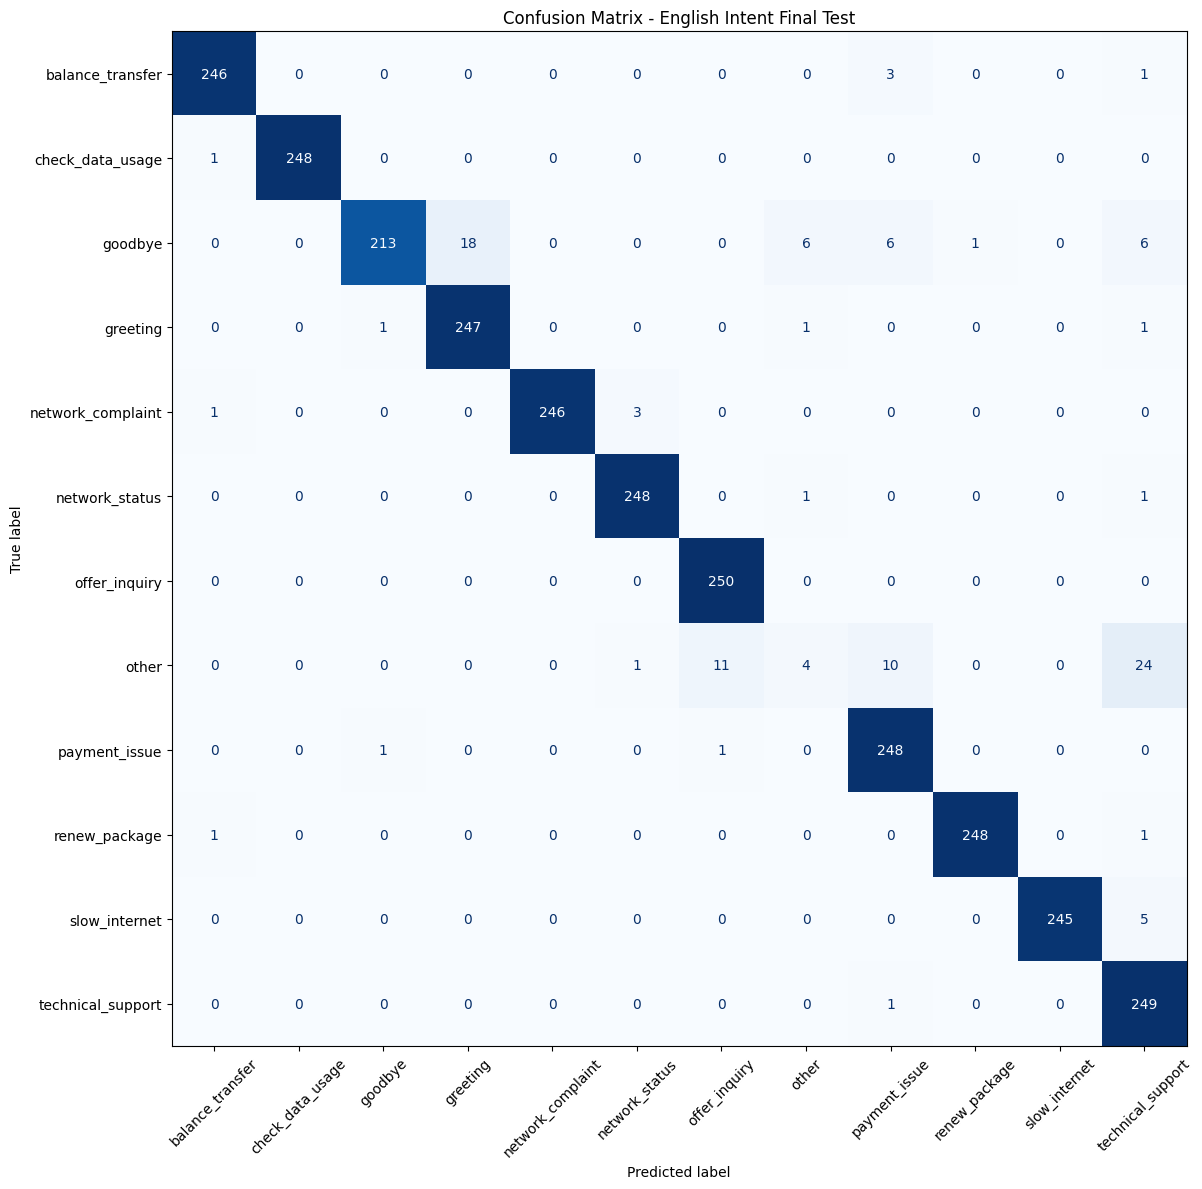


Saved to: intent_english_final_predictions.csv

Wrong predictions: 107
                                                   text  \
5     After recharging, what's my data balance for t...   
250   What's the way to extend my current subscription?   
313                I want to extend my internet bundle.   
529   Talk to you later since this morning — payment...   
600                                        cnew world?    
763                I need assistance moving my balance.   
952          are there any charges for receiving money?   
988                              can i cancel a charge?   
990                              can i cancel a charge?   
1255            Signal exists but internet is dragging.   
1260           Signal exists, but internet is dragging.   
1343         I want to fix my internet since yesterday.   
1348                           data connection problem?   
1387                           internet not responding?   
1745  Please walk me through fixing this te

In [23]:
import pandas as pd
import torch
import re
import pickle
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==============================
# 1) PATHS
# ==============================
test_path = "intent_test_english.csv"

model_path = "/content/drive/MyDrive/CoCare/intent_Eng/distilbert_intent_model_only"
label_encoder_path = "/content/drive/MyDrive/CoCare/intent_Eng/distilbert_label_encoder.pkl"

output_path = "intent_english_final_predictions.csv"

# ==============================
# 2) LOAD TEST DATA
# ==============================
df = pd.read_csv(test_path)

text_col = "text_en" if "text_en" in df.columns else "text"
intent_col = "intent_en" if "intent_en" in df.columns else "intent"

df = df[[text_col, intent_col]].dropna().copy()
df.columns = ["text", "true_intent"]

# ==============================
# 3) CLEAN TEXT
# ==============================
def clean_text(text):
    text = str(text).strip().lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df["true_intent"] = df["true_intent"].astype(str).str.strip().str.lower()

bad_labels = ["", "nan", "none", "null", "0"]
df = df[~df["true_intent"].isin(bad_labels)].copy()
df = df[df["clean_text"] != ""].copy()

# ==============================
# 4) IMPORTANT FIX
# ==============================
df = df[df["true_intent"] != "thanks"].copy()

# ==============================
# 5) LOAD MODEL
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.to(device)
model.eval()

with open(label_encoder_path, "rb") as f:
    le = pickle.load(f)

print("Model labels:")
print(list(le.classes_))

print("\nTest labels:")
print(sorted(df["true_intent"].unique()))

print("\nMissing in model:")
print(set(df["true_intent"]) - set(le.classes_))

# ==============================
# 6) PREDICT
# ==============================
texts = df["clean_text"].tolist()

preds = []
scores = []

batch_size = 32
threshold = 0.30

with torch.no_grad():
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        enc = tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors="pt"
        )

        enc = {k: v.to(device) for k, v in enc.items()}

        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1)

        best_scores, best_ids = torch.max(probs, dim=-1)

        for label_id, score in zip(best_ids.cpu().numpy(), best_scores.cpu().numpy()):
            label_name = le.inverse_transform([int(label_id)])[0]
            label_name = str(label_name).strip().lower()
            score = float(score)

            # fallback للثقة الضعيفة
            if score < threshold:
                label_name = "other"

            preds.append(label_name)
            scores.append(score)

df["pred"] = preds
df["score"] = scores

# ==============================
# 7) REMOVE INVALID PREDICTIONS
# ==============================
valid_labels = set(df["true_intent"].unique())

df["pred"] = df["pred"].apply(
    lambda x: x if x in valid_labels else "other"
)

# ==============================
# 8) METRICS
# ==============================
y_true = df["true_intent"]
y_pred = df["pred"]

accuracy = accuracy_score(y_true, y_pred)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("\nFINAL TEST RESULTS")
print("Accuracy:", accuracy)
print("F1 Weighted:", f1_weighted)
print("F1 Macro:", f1_macro)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

print("\nPrediction distribution:")
print(df["pred"].value_counts())

# ==============================
# 9) CONFUSION MATRIX
# ==============================
labels = sorted(set(y_true) | set(y_pred))

cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - English Intent Final Test")
plt.tight_layout()
plt.show()

# ==============================
# 10) SAVE RESULTS
# ==============================
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print("\nSaved to:", output_path)

# ==============================
# 11) SHOW ERRORS
# ==============================
errors_df = df[df["true_intent"] != df["pred"]].copy()

print("\nWrong predictions:", len(errors_df))

if len(errors_df) > 0:
    print(errors_df[["text", "clean_text", "true_intent", "pred", "score"]].head(50))